In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

os.chdir('/Users/enzoa/OneDrive/Área de Trabalho/vscode/Japantrap')

FileNotFoundError: [WinError 3] O sistema não pode encontrar o caminho especificado: '/Users/enzoa/OneDrive/Área de Trabalho/vscode/Japantrap'

In [ ]:
cols = ['_', 'CY', 'Q', 'Model 1', 'Model 2', 'Model 3',
        'Model 4', 'Model 5', 'Model 6']
nat = pd.read_excel('rev26e04b.xlsx', sheet_name='Chart 3', skiprows=3, names=cols).drop(columns='_')
nat = nat[['Q', 'Model 2']].dropna(subset=['Q'])
nat = nat.rename(columns={'Model 2': 'natural_rate'})
nat['period'] = pd.PeriodIndex.from_fields(
    year=nat['Q'].astype(str).str[:4].astype(int),
    quarter=nat['Q'].astype(str).str[-1].astype(int), freq='Q')
df_trim = nat.set_index('period')[['natural_rate']]

cpi = pd.read_excel('CPALTT01JPQ657N.xlsx', sheet_name='Quarterly')
cpi['period'] = pd.to_datetime(cpi['observation_date']).dt.to_period('Q')
cpi = cpi.rename(columns={'CPALTT01JPQ657N': 'cpi_qoq'}).set_index('period')
cpi['cpi_inflacao'] = cpi['cpi_qoq'].rolling(4).sum()
df_trim = df_trim.join(cpi[['cpi_inflacao']])

gap_q = pd.read_excel('gap.xlsx', sheet_name='data1', skiprows=5,
                      header=None, usecols=[0, 1], names=['Q', 'output_gap'])
gap_q = gap_q.dropna(subset=['Q'])
gap_q['period'] = pd.PeriodIndex.from_fields(
    year=gap_q['Q'].astype(str).str[:4].astype(int),
    quarter=gap_q['Q'].astype(str).str[5].astype(int), freq='Q')
df_trim = df_trim.join(gap_q.set_index('period')[['output_gap']])

df_trim = df_trim.loc['1993Q1':'2021Q2']
df_trim['pi_lag']  = df_trim['cpi_inflacao'].shift(1)
df_trim['pi_lead'] = df_trim['cpi_inflacao'].shift(-1)

NameError: name 'pd' is not defined

In [ ]:
def rodar_phillips(df, x_cols):
    d = df[['cpi_inflacao'] + x_cols].dropna()
    y = d['cpi_inflacao']
    X = sm.add_constant(d[x_cols])
    return sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print("\n" + "="*70)
print("PHILLIPS COM LAG: pi_t = a + b*gap + g*pi_{t-1} + e")
print("="*70)
m_lag = rodar_phillips(df_trim, ['output_gap', 'pi_lag'])
print(m_lag.summary())

print("\n" + "="*70)
print("PHILLIPS HÍBRIDA: pi_t = a + b*gap + g*pi_{t-1} + d*pi_{t+1} + e")
print("="*70)
m_hib = rodar_phillips(df_trim, ['output_gap', 'pi_lag', 'pi_lead'])
print(m_hib.summary())

g = m_hib.params['pi_lag']
d = m_hib.params['pi_lead']
print(f"\ngamma + delta = {g + d:.4f}")
print(f"gamma/(gamma+delta) = {g/(g+d):.4f}")


PHILLIPS COM LAG: pi_t = a + b*gap + g*pi_{t-1} + e
                            OLS Regression Results                            
Dep. Variable:           cpi_inflacao   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     97.56
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           4.27e-25
Time:                        16:10:02   Log-Likelihood:                -86.068
No. Observations:                 113   AIC:                             178.1
Df Residuals:                     110   BIC:                             186.3
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [ ]:
print("\n" + "="*70)
print("TESTES DE RAIZ UNITÁRIA")
print("="*70)
for col in ['cpi_inflacao', 'output_gap', 'natural_rate']:
    s = df_trim[col].dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    print(f"\n{col} (n={len(s)}):")
    print(f"  ADF:  stat={adf_stat:>7.3f}  p={adf_p:.3f}  "
          f"-> {'ESTACIONÁRIA' if adf_p<0.05 else 'não rejeita raiz unitária'}")
    print(f"  KPSS: stat={kpss_stat:>7.3f}  p={kpss_p:.3f}  "
          f"-> {'NÃO estacionária' if kpss_p<0.05 else 'consistente com estacionariedade'}")


TESTES DE RAIZ UNITÁRIA

cpi_inflacao (n=114):
  ADF:  stat= -3.392  p=0.011  -> ESTACIONÁRIA
  KPSS: stat=  0.134  p=0.100  -> consistente com estacionariedade

output_gap (n=114):
  ADF:  stat= -3.276  p=0.016  -> ESTACIONÁRIA
  KPSS: stat=  0.506  p=0.040  -> NÃO estacionária

natural_rate (n=114):
  ADF:  stat= -2.086  p=0.250  -> não rejeita raiz unitária
  KPSS: stat=  1.367  p=0.010  -> NÃO estacionária


In [ ]:
print("\n" + "="*70)
print("AUTOCORRELAÇÕES")
print("="*70)
print(f"{'Variável':>22} {'rho(1)':>8} {'rho(2)':>8} {'rho(4)':>8} {'rho(8)':>8} {'rho(12)':>8}")
for col in ['cpi_inflacao', 'output_gap', 'natural_rate']:
    s = df_trim[col].dropna().values
    vals = []
    for k in [1, 2, 4, 8, 12]:
        if k < len(s):
            ac = np.corrcoef(s[k:], s[:-k])[0, 1]
            vals.append(f"{ac:>8.3f}")
        else:
            vals.append(f"{'-':>8}")
    print(f"{col:>22} " + " ".join(vals))


AUTOCORRELAÇÕES
              Variável   rho(1)   rho(2)   rho(4)   rho(8)  rho(12)
          cpi_inflacao    0.819    0.630    0.154   -0.101   -0.013
            output_gap    0.911    0.766    0.492    0.150    0.032
          natural_rate    0.997    0.987    0.950    0.819    0.676


In [ ]:
print("\n" + "="*70)
print("PHILLIPS POR SUBAMOSTRAS")
print("="*70)
subamostras = [
    ("1993Q1-1997Q4 (pré-armadilha)",         slice('1993Q1', '1997Q4')),
    ("1998Q1-2012Q4 (armadilha consolidada)", slice('1998Q1', '2012Q4')),
    ("2013Q1-2021Q2 (Abenomics)",              slice('2013Q1', '2021Q2')),
]
sub_models, sub_labels_tab = [], []
for label, periodo in subamostras:
    sub = df_trim.loc[periodo, ['cpi_inflacao', 'output_gap', 'pi_lag']].dropna()
    y = sub['cpi_inflacao']
    X = sm.add_constant(sub[['output_gap', 'pi_lag']])
    m = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    sub_models.append(m)
    sub_labels_tab.append(label.replace(' (', '\n('))
    print(f"\n{label} (n={int(m.nobs)})")
    print(f"  alpha = {m.params['const']:>8.4f}  p={m.pvalues['const']:.3f}")
    print(f"  beta  = {m.params['output_gap']:>8.4f}  p={m.pvalues['output_gap']:.3f}")
    print(f"  gamma = {m.params['pi_lag']:>8.4f}  p={m.pvalues['pi_lag']:.3f}")


PHILLIPS POR SUBAMOSTRAS

1993Q1-1997Q4 (pré-armadilha) (n=19)
  alpha =   0.3455  p=0.003
  beta  =   0.3333  p=0.022
  gamma =   0.8189  p=0.000

1998Q1-2012Q4 (armadilha consolidada) (n=60)
  alpha =   0.1454  p=0.123
  beta  =   0.1863  p=0.000
  gamma =   0.6301  p=0.000

2013Q1-2021Q2 (Abenomics) (n=34)
  alpha =   0.0737  p=0.545
  beta  =   0.0912  p=0.232
  gamma =   0.8031  p=0.000


In [ ]:
def fmt(coef, se, p):
    stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    return f"{coef:.3f}{stars}\n({se:.3f})"

def style_table(tab):
    tab.auto_set_font_size(False); tab.set_fontsize(10); tab.scale(1, 2.0)
    for (row, col), cell in tab.get_celld().items():
        if row == 0:
            cell.set_facecolor('#1f4e79')
            cell.set_text_props(color='white', weight='bold')
        elif col == -1:
            cell.set_facecolor('#f2f2f2'); cell.set_text_props(weight='bold')

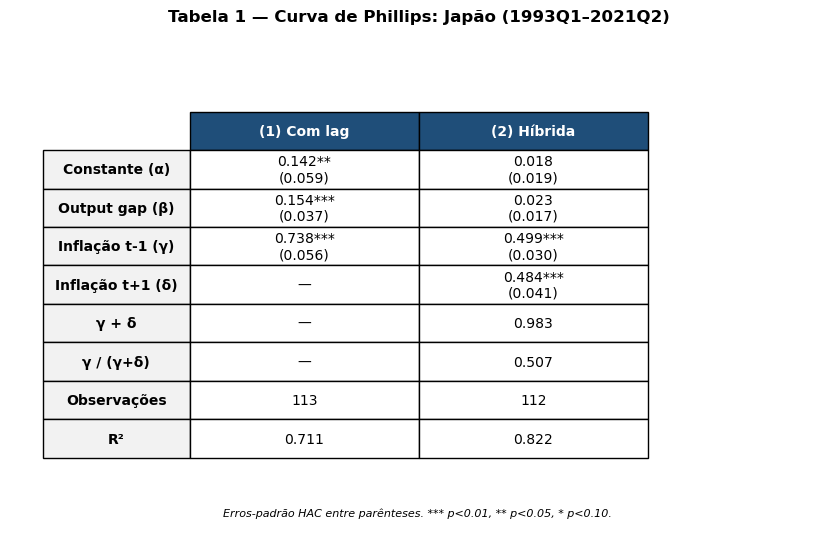

In [ ]:
col1 = [fmt(m_lag.params['const'], m_lag.bse['const'], m_lag.pvalues['const']),
        fmt(m_lag.params['output_gap'], m_lag.bse['output_gap'], m_lag.pvalues['output_gap']),
        fmt(m_lag.params['pi_lag'], m_lag.bse['pi_lag'], m_lag.pvalues['pi_lag']),
        '—', '—', '—', f"{int(m_lag.nobs)}", f"{m_lag.rsquared:.3f}"]
col2 = [fmt(m_hib.params['const'], m_hib.bse['const'], m_hib.pvalues['const']),
        fmt(m_hib.params['output_gap'], m_hib.bse['output_gap'], m_hib.pvalues['output_gap']),
        fmt(m_hib.params['pi_lag'], m_hib.bse['pi_lag'], m_hib.pvalues['pi_lag']),
        fmt(m_hib.params['pi_lead'], m_hib.bse['pi_lead'], m_hib.pvalues['pi_lead']),
        f"{g+d:.3f}", f"{g/(g+d):.3f}", f"{int(m_hib.nobs)}", f"{m_hib.rsquared:.3f}"]

fig, ax = plt.subplots(figsize=(8.5, 5.5)); ax.axis('off')
tab = ax.table(cellText=[[a, b] for a, b in zip(col1, col2)],
               rowLabels=['Constante (α)', 'Output gap (β)', 'Inflação t-1 (γ)',
                          'Inflação t+1 (δ)', 'γ + δ', 'γ / (γ+δ)', 'Observações', 'R²'],
               colLabels=['(1) Com lag', '(2) Híbrida'],
               cellLoc='center', rowLoc='center', loc='center', colWidths=[0.28, 0.28])
style_table(tab)
plt.title('Tabela 1 — Curva de Phillips: Japão (1993Q1–2021Q2)',
          fontsize=12, weight='bold', pad=14)
plt.figtext(0.5, 0.05, 'Erros-padrão HAC entre parênteses. *** p<0.01, ** p<0.05, * p<0.10.',
            ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('tabela1_phillips.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

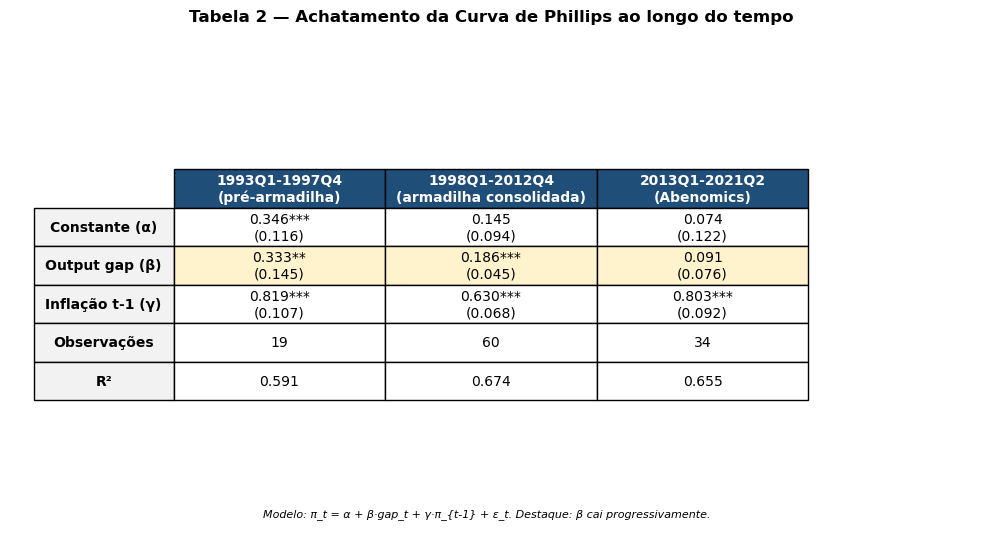

In [ ]:
cells2 = []
for name in ['const', 'output_gap', 'pi_lag']:
    cells2.append([fmt(m.params[name], m.bse[name], m.pvalues[name]) for m in sub_models])
cells2.append([f"{int(m.nobs)}" for m in sub_models])
cells2.append([f"{m.rsquared:.3f}" for m in sub_models])

fig, ax = plt.subplots(figsize=(10, 5.5)); ax.axis('off')
tab = ax.table(cellText=cells2,
               rowLabels=['Constante (α)', 'Output gap (β)', 'Inflação t-1 (γ)',
                          'Observações', 'R²'],
               colLabels=sub_labels_tab, cellLoc='center', rowLoc='center',
               loc='center', colWidths=[0.22, 0.22, 0.22])
style_table(tab)
for col in range(3):
    tab[(2, col)].set_facecolor('#fff3cd')
plt.title('Tabela 2 — Achatamento da Curva de Phillips ao longo do tempo',
          fontsize=12, weight='bold', pad=14)
plt.figtext(0.5, 0.05,
            'Modelo: π_t = α + β·gap_t + γ·π_{t-1} + ε_t. Destaque: β cai progressivamente.',
            ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('tabela2_subamostras.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

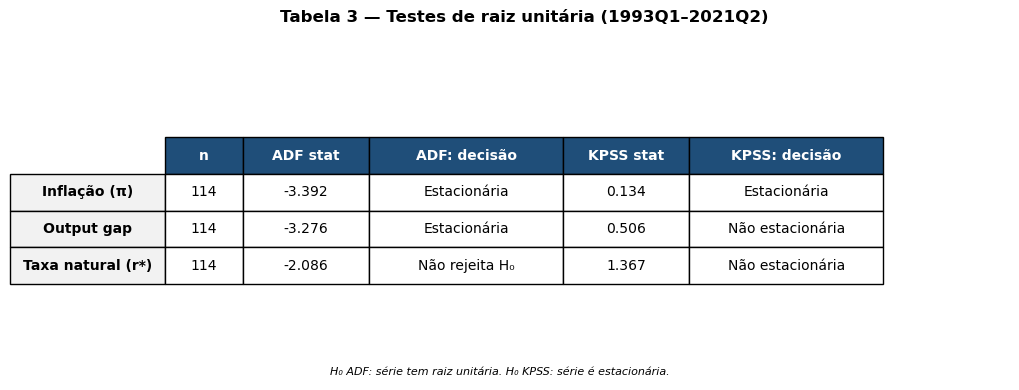

In [ ]:

rows3 = []
for col in ['cpi_inflacao', 'output_gap', 'natural_rate']:
    s = df_trim[col].dropna()
    a_stat, a_p, *_ = adfuller(s, autolag='AIC')
    k_stat, k_p, *_ = kpss(s, regression='c', nlags='auto')
    rows3.append([f"{len(s)}", f"{a_stat:.3f}",
                  'Estacionária' if a_p<0.05 else 'Não rejeita H₀',
                  f"{k_stat:.3f}",
                  'Não estacionária' if k_p<0.05 else 'Estacionária'])

fig, ax = plt.subplots(figsize=(10.5, 4)); ax.axis('off')
tab = ax.table(cellText=rows3,
               rowLabels=['Inflação (π)', 'Output gap', 'Taxa natural (r*)'],
               colLabels=['n', 'ADF stat', 'ADF: decisão', 'KPSS stat', 'KPSS: decisão'],
               cellLoc='center', rowLoc='center', loc='center',
               colWidths=[0.08, 0.13, 0.20, 0.13, 0.20])
style_table(tab)
plt.title('Tabela 3 — Testes de raiz unitária (1993Q1–2021Q2)',
          fontsize=12, weight='bold', pad=14)
plt.figtext(0.5, 0.05,
            'H₀ ADF: série tem raiz unitária. H₀ KPSS: série é estacionária.',
            ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('tabela3_raiz_unitaria.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

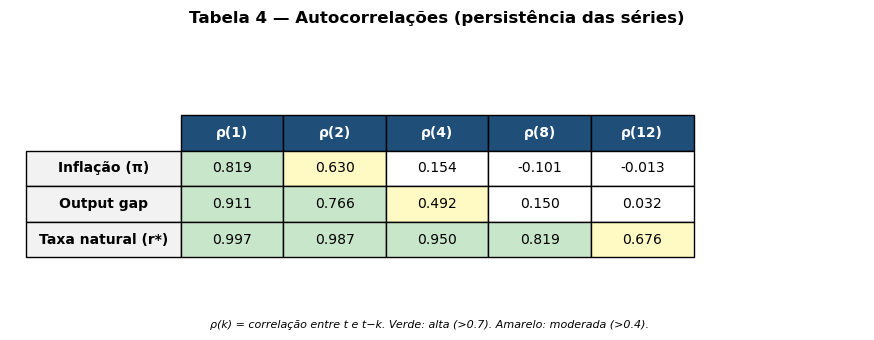

In [ ]:

rows4 = []
for col in ['cpi_inflacao', 'output_gap', 'natural_rate']:
    s = df_trim[col].dropna().values
    rows4.append([f"{np.corrcoef(s[k:], s[:-k])[0,1]:.3f}" for k in [1, 2, 4, 8, 12]])

fig, ax = plt.subplots(figsize=(9, 3.5)); ax.axis('off')
tab = ax.table(cellText=rows4,
               rowLabels=['Inflação (π)', 'Output gap', 'Taxa natural (r*)'],
               colLabels=['ρ(1)', 'ρ(2)', 'ρ(4)', 'ρ(8)', 'ρ(12)'],
               cellLoc='center', rowLoc='center', loc='center', colWidths=[0.12]*5)
style_table(tab)
for row in range(1, 4):
    for col in range(5):
        try:
            v = float(rows4[row-1][col])
            if v > 0.7:   tab[(row, col)].set_facecolor('#c8e6c9')
            elif v > 0.4: tab[(row, col)].set_facecolor('#fff9c4')
        except: pass
plt.title('Tabela 4 — Autocorrelações (persistência das séries)',
          fontsize=12, weight='bold', pad=14)
plt.figtext(0.5, 0.05,
            'ρ(k) = correlação entre t e t−k. Verde: alta (>0.7). Amarelo: moderada (>0.4).',
            ha='center', fontsize=8, style='italic')
plt.tight_layout()
plt.savefig('tabela4_autocorrelacao.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

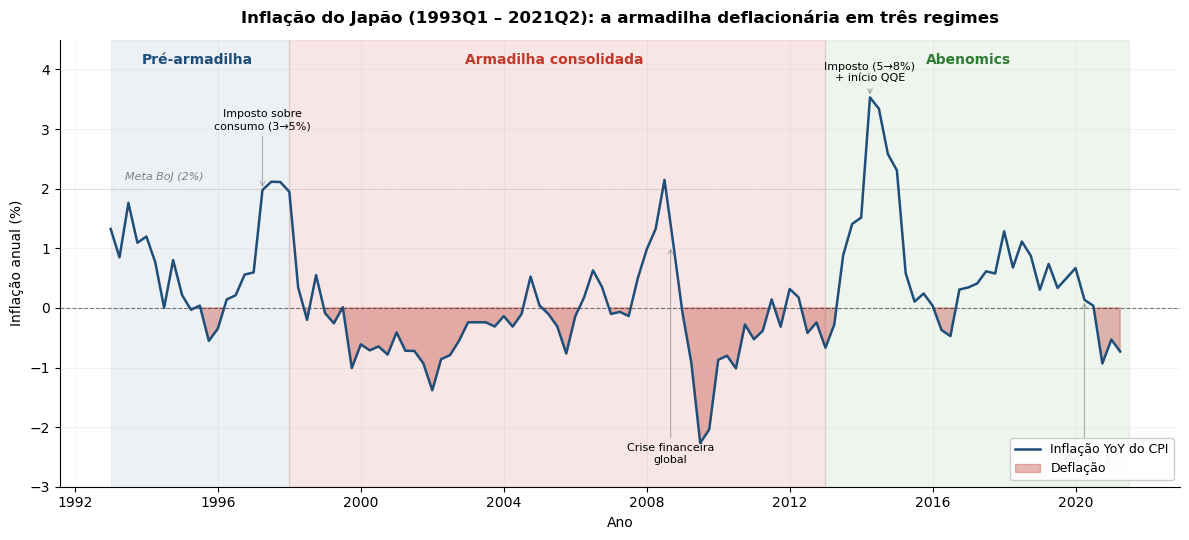

In [ ]:
df_inf = df_trim.copy()
df_inf.index = df_inf.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5.5)); fig.patch.set_facecolor('white')

ax.axvspan(pd.Timestamp('1993-01-01'), pd.Timestamp('1998-01-01'),
           alpha=0.08, color='#1f4e79')
ax.axvspan(pd.Timestamp('1998-01-01'), pd.Timestamp('2013-01-01'),
           alpha=0.12, color='#c0392b')
ax.axvspan(pd.Timestamp('2013-01-01'), pd.Timestamp('2021-07-01'),
           alpha=0.08, color='#2e7d32')
ax.set_ylim(-3.0, 4.5)

for x, txt, cor in [(pd.Timestamp('1995-06-01'), 'Pré-armadilha', '#1f4e79'),
                    (pd.Timestamp('2005-06-01'), 'Armadilha consolidada', '#c0392b'),
                    (pd.Timestamp('2017-01-01'), 'Abenomics', '#2e7d32')]:
    ax.text(x, 4.1, txt, ha='center', fontsize=10, color=cor, weight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(2, color='gray', linewidth=0.7, linestyle=':', alpha=0.5)
ax.text(pd.Timestamp('1993-06-01'), 2.15, 'Meta BoJ (2%)',
        fontsize=8, color='gray', style='italic')

ax.plot(df_inf.index, df_inf['cpi_inflacao'],
        color='#1f4e79', linewidth=1.8, label='Inflação YoY do CPI')
ax.fill_between(df_inf.index, df_inf['cpi_inflacao'], 0,
                where=(df_inf['cpi_inflacao'] < 0),
                color='#c0392b', alpha=0.35, interpolate=True, label='Deflação')

for data, texto, ypos in [('1997-04-01', 'Imposto sobre\nconsumo (3→5%)', 3.0),
                          ('2008-09-01', 'Crise financeira\nglobal', -2.6),
                          ('2014-04-01', 'Imposto (5→8%)\n+ início QQE', 3.8),
                          ('2020-04-01', 'COVID-19', -2.6)]:
    ts = pd.Timestamp(data)
    valor = df_inf['cpi_inflacao'].iloc[df_inf.index.get_indexer([ts], method='nearest')[0]]
    ax.annotate(texto, xy=(ts, valor), xytext=(ts, ypos),
                fontsize=8, ha='center',
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6, lw=0.8))

ax.set_xlabel('Ano', fontsize=10)
ax.set_ylabel('Inflação anual (%)', fontsize=10)
ax.set_title('Inflação do Japão (1993Q1 – 2021Q2): a armadilha deflacionária em três regimes',
             fontsize=12, weight='bold', pad=12)
ax.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax.grid(alpha=0.25, linewidth=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('visão_geral.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()